# Assignment 4: Performance Comparison of Ensemble Learning Models

**Name:** Moh. Fawad Karimi

**NPM:** 250820701100011

**Course:** Machine Learning 

---

This notebook compares the performance of:
1. Decision Tree
2. Naive Bayes
3. Ensemble — Bagging Random Forest (k = 5, 10, 20, 50)
4. Ensemble — Random Vector Random Forest (k = 5, 10, 20, 50)

## Install Required Libraries

Run this cell once if the packages are not yet installed.

## Step 1 — Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE

np.random.seed(42)
print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2 — Create Mock Family Economic Background Dataset

The dataset has 526 samples, 13 features (10 continuous + 3 categorical), and 5 class labels representing socioeconomic strata.

In [7]:
# Generate base dataset: 526 samples, 5 classes
X, y = make_classification(
    n_samples=526,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_classes=5,
    n_clusters_per_class=1,
    weights=[0.25, 0.20, 0.20, 0.20, 0.15],
    random_state=42
)

# Add 3 categorical features (encoded as integers)
cat1 = np.random.choice([0, 1, 2],    size=526)   # education level
cat2 = np.random.choice([0, 1],       size=526)   # employment status
cat3 = np.random.choice([0, 1, 2, 3], size=526)   # housing type
X = np.column_stack([X, cat1, cat2, cat3])

# Wrap in DataFrame for display
feature_names = (
    [f'feature_{i}' for i in range(10)] +
    ['education_level', 'employment_status', 'housing_type']
)
df_full = pd.DataFrame(X, columns=feature_names)
df_full['class_label'] = y

print('Dataset shape:', df_full.shape)
print('\nClass distribution (original):')
print(df_full['class_label'].value_counts().sort_index())
df_full.head()

Dataset shape: (526, 14)

Class distribution (original):
class_label
0    128
1    108
2    106
3    106
4     78
Name: count, dtype: int64


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,education_level,employment_status,housing_type,class_label
0,5.856137,2.593743,-0.481689,-0.982447,0.553956,1.377757,4.411427,-2.950171,1.969138,0.131406,2.0,1.0,2.0,2
1,-0.200951,0.672154,-1.322261,-0.781049,-0.002010,-1.508910,-0.109382,0.976226,-2.536143,-2.481489,0.0,0.0,2.0,2
2,0.069272,0.189238,1.119464,-2.928699,-1.653582,0.494741,1.560488,-2.353773,1.253501,-0.038376,2.0,1.0,3.0,3
3,0.273405,-0.280118,2.590723,0.416843,-1.529833,-3.710892,0.898261,-0.472547,-0.274761,-0.995050,2.0,1.0,0.0,4
4,-0.304929,-0.403504,0.832692,0.164543,-0.017935,-1.090287,1.117937,-0.675551,0.606149,0.397106,0.0,0.0,1.0,4


## Step 3 — Visualize Original Class Distribution

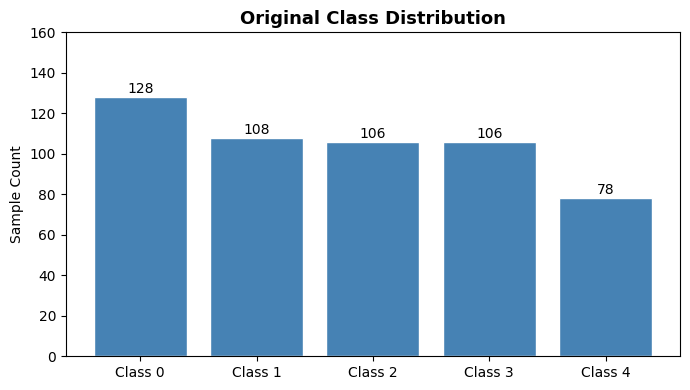

Original counts: [128 108 106 106  78]


In [8]:
orig_counts = np.bincount(y)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f'Class {i}' for i in range(5)], orig_counts, color='steelblue', edgecolor='white')
ax.set_title('Original Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Sample Count')
ax.set_ylim(0, 160)
for i, v in enumerate(orig_counts):
    ax.text(i, v + 2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_class_dist_original.png', dpi=120)
plt.show()
print('Original counts:', orig_counts)

## Step 4 — Apply SMOTE to Balance Classes

After SMOTE — class distribution: [128 128 128 128 128]
Total samples after SMOTE: 640


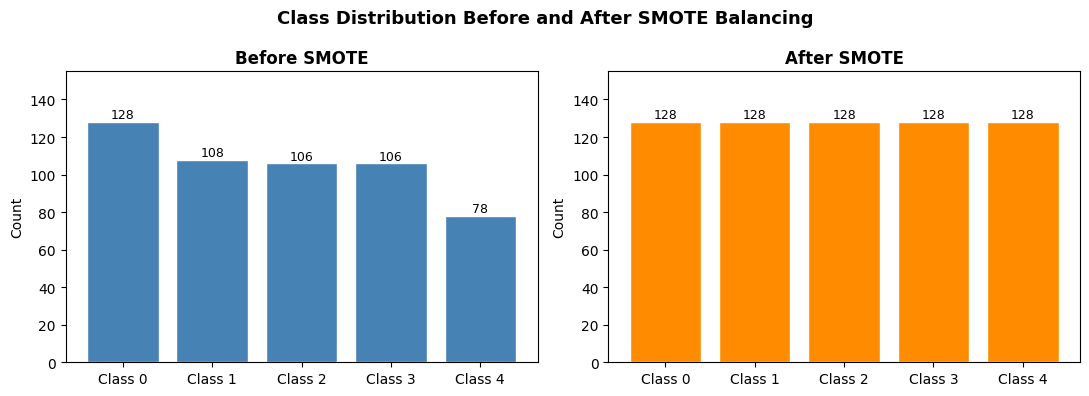

In [9]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

after_counts = np.bincount(y_res)
print('After SMOTE — class distribution:', after_counts)
print('Total samples after SMOTE:', len(y_res))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar([f'Class {i}' for i in range(5)], orig_counts,  color='steelblue',  edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, 155)
for i, v in enumerate(orig_counts):  axes[0].text(i, v+2, str(v), ha='center', fontsize=9)

axes[1].bar([f'Class {i}' for i in range(5)], after_counts, color='darkorange', edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].set_ylim(0, 155)
for i, v in enumerate(after_counts): axes[1].text(i, v+2, str(v), ha='center', fontsize=9)

plt.suptitle('Class Distribution Before and After SMOTE Balancing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_class_dist.png', dpi=120)
plt.show()

## Step 5 — Train/Test Split (80% / 20%, Stratified)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# Standardize features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training set : {X_train_s.shape[0]} samples')
print(f'Test set     : {X_test_s.shape[0]} samples')
print(f'Features     : {X_train_s.shape[1]}')
print(f'\nTrain class distribution: {np.bincount(y_train)}')
print(f'Test  class distribution: {np.bincount(y_test)}')

Training set : 512 samples
Test set     : 128 samples
Features     : 13

Train class distribution: [102 103 102 102 103]
Test  class distribution: [26 25 26 26 25]


## Step 6 — Define Metric Computation Function

In [11]:
def compute_metrics(model_name, y_true, y_pred):
    """
    Compute macro-averaged TPR, FPR, Precision, Recall, and F1
    for a multi-class prediction.
    """
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]
    tpr_list, fpr_list = [], []

    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0.0)

    return {
        'Model'    : model_name,
        'TPR'      : np.mean(tpr_list),
        'FPR'      : np.mean(fpr_list),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall'   : recall_score   (y_true, y_pred, average='macro', zero_division=0),
        'F1'       : f1_score       (y_true, y_pred, average='macro', zero_division=0),
    }

print('compute_metrics() ready.')

compute_metrics() ready.


## Step 7 — Train All Models and Collect Results

In [12]:
results = []

# ── (1) Decision Tree ─────────────────────────────────────────────────────────
print('Training Decision Tree...', end=' ')
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_s, y_train)
results.append(compute_metrics('Decision Tree', y_test, dt.predict(X_test_s)))
print('Done.')

# ── (2) Naive Bayes ───────────────────────────────────────────────────────────
print('Training Naive Bayes...', end=' ')
nb = GaussianNB()
nb.fit(X_train_s, y_train)
results.append(compute_metrics('Naive Bayes', y_test, nb.predict(X_test_s)))
print('Done.')

# ── (3) Bagging Random Forest ─────────────────────────────────────────────────
for k in [5, 10, 20, 50]:
    print(f'Training Bagging RF k={k}...', end=' ')
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=k,
        bootstrap=True,
        random_state=42
    )
    bag.fit(X_train_s, y_train)
    results.append(compute_metrics(f'Bagging RF k={k}', y_test, bag.predict(X_test_s)))
    print('Done.')

# ── (4) Random Vector Random Forest ──────────────────────────────────────────
for k in [5, 10, 20, 50]:
    print(f'Training Random Vector RF k={k}...', end=' ')
    rf = RandomForestClassifier(
        n_estimators=k,
        max_features='sqrt',
        random_state=42
    )
    rf.fit(X_train_s, y_train)
    results.append(compute_metrics(f'Random Vector RF k={k}', y_test, rf.predict(X_test_s)))
    print('Done.')

print('\nAll models trained successfully.')

Training Decision Tree... Done.
Training Naive Bayes... Done.
Training Bagging RF k=5... Done.
Training Bagging RF k=10... Done.
Training Bagging RF k=20... Done.
Training Bagging RF k=50... Done.
Training Random Vector RF k=5... Done.
Training Random Vector RF k=10... Done.
Training Random Vector RF k=20... Done.
Training Random Vector RF k=50... Done.

All models trained successfully.


## Step 8 — Display Results Table

In [13]:
df_results = pd.DataFrame(results)

# Format for display
df_display = df_results.copy()
for col in ['TPR', 'FPR', 'Precision', 'Recall', 'F1']:
    df_display[col] = df_display[col].map('{:.4f}'.format)

print('\n===== Performance Metrics (Macro-Averaged) =====')
print(df_display.to_string(index=False))

# Save to CSV
df_results.to_csv('results.csv', index=False)
print('\nResults saved to results.csv')


===== Performance Metrics (Macro-Averaged) =====
                Model    TPR    FPR Precision Recall     F1
        Decision Tree 0.7969 0.0508    0.8044 0.7969 0.7962
          Naive Bayes 0.8443 0.0390    0.8453 0.8443 0.8429
       Bagging RF k=5 0.8594 0.0352    0.8618 0.8594 0.8596
      Bagging RF k=10 0.8905 0.0274    0.8927 0.8905 0.8906
      Bagging RF k=20 0.8828 0.0293    0.8837 0.8828 0.8818
      Bagging RF k=50 0.8831 0.0293    0.8818 0.8831 0.8804
 Random Vector RF k=5 0.8215 0.0449    0.8314 0.8215 0.8208
Random Vector RF k=10 0.8209 0.0449    0.8327 0.8209 0.8215
Random Vector RF k=20 0.8514 0.0371    0.8570 0.8514 0.8515
Random Vector RF k=50 0.8902 0.0273    0.8913 0.8902 0.8901

Results saved to results.csv


## Step 9 — Figure 2: Base Model Comparison (Decision Tree vs Naive Bayes)

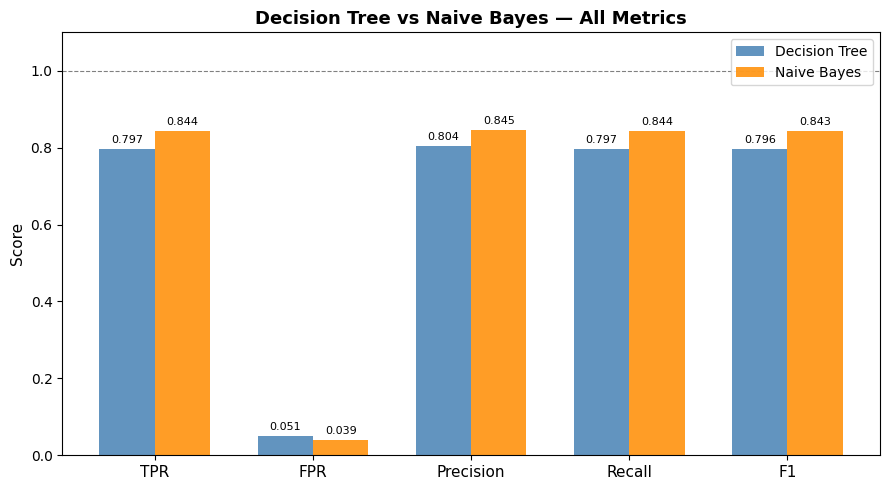

In [14]:
metrics = ['TPR', 'FPR', 'Precision', 'Recall', 'F1']
base = df_results[df_results['Model'].isin(['Decision Tree', 'Naive Bayes'])].reset_index(drop=True)

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, base.loc[0, metrics].values, w, label='Decision Tree', color='steelblue',  alpha=0.85)
ax.bar(x + w/2, base.loc[1, metrics].values, w, label='Naive Bayes',   color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Decision Tree vs Naive Bayes — All Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(1.0, color='gray', lw=0.8, ls='--')

for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig_base_compare.png', dpi=120)
plt.show()

## Step 10 — Figure 3: Ensemble F1 vs k (Number of Estimators)

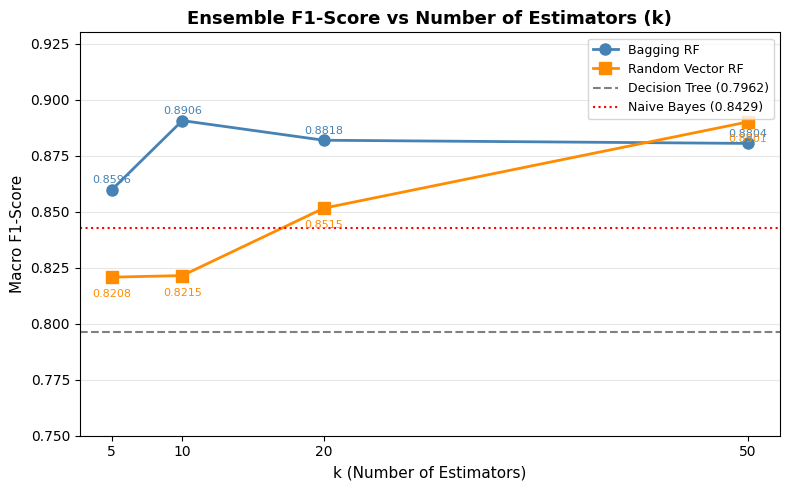

In [15]:
ks = [5, 10, 20, 50]

bag_f1 = df_results[df_results['Model'].str.startswith('Bagging RF')]['F1'].values
rv_f1  = df_results[df_results['Model'].str.startswith('Random Vector')]['F1'].values
dt_f1  = df_results[df_results['Model'] == 'Decision Tree']['F1'].values[0]
nb_f1  = df_results[df_results['Model'] == 'Naive Bayes']['F1'].values[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, bag_f1, 'o-', color='steelblue',  lw=2, ms=8, label='Bagging RF')
ax.plot(ks, rv_f1,  's-', color='darkorange', lw=2, ms=8, label='Random Vector RF')
ax.axhline(dt_f1, ls='--', color='gray', lw=1.5, label=f'Decision Tree ({dt_f1:.4f})')
ax.axhline(nb_f1, ls=':',  color='red',  lw=1.5, label=f'Naive Bayes ({nb_f1:.4f})')

# Annotate points
for k, b, r in zip(ks, bag_f1, rv_f1):
    ax.text(k, b + 0.003, f'{b:.4f}', ha='center', fontsize=8, color='steelblue')
    ax.text(k, r - 0.009, f'{r:.4f}', ha='center', fontsize=8, color='darkorange')

ax.set_xlabel('k (Number of Estimators)', fontsize=11)
ax.set_ylabel('Macro F1-Score', fontsize=11)
ax.set_title('Ensemble F1-Score vs Number of Estimators (k)', fontsize=13, fontweight='bold')
ax.set_ylim(0.75, 0.93)
ax.set_xticks(ks)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_ensemble_k.png', dpi=120)
plt.show()

## Step 11 — Figure 4: Full Metrics Heatmap

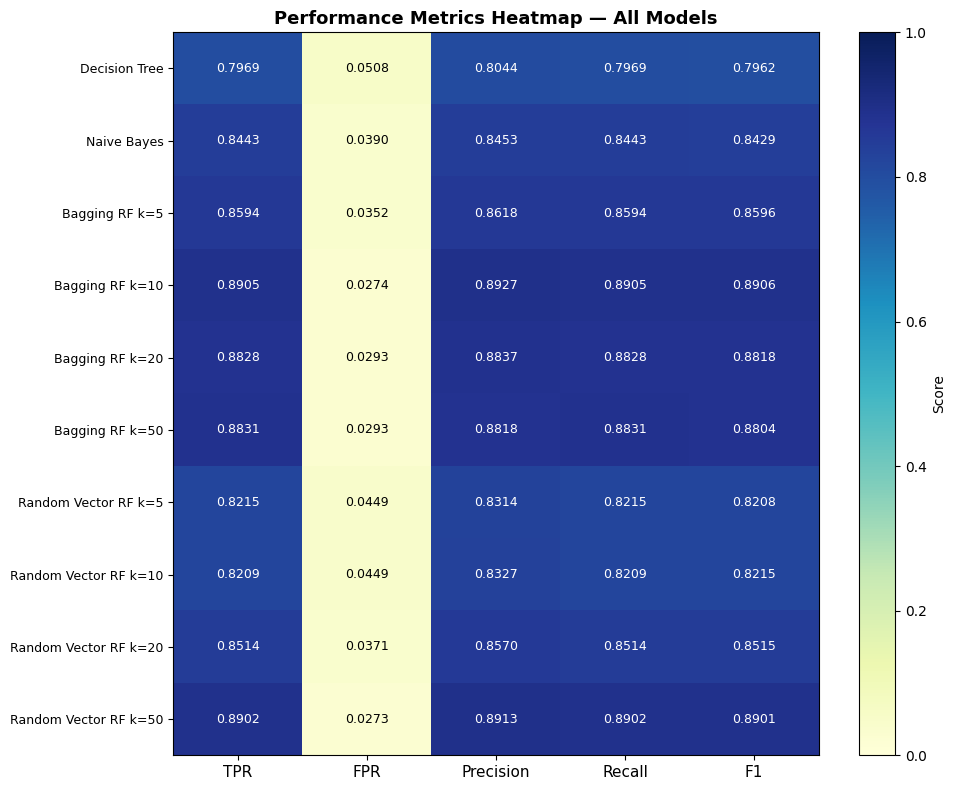

In [16]:
heat_df = df_results.set_index('Model')[['TPR', 'FPR', 'Precision', 'Recall', 'F1']]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heat_df.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)

ax.set_xticks(range(5))
ax.set_xticklabels(heat_df.columns, fontsize=11)
ax.set_yticks(range(len(heat_df)))
ax.set_yticklabels(heat_df.index, fontsize=9)

for i in range(len(heat_df)):
    for j in range(5):
        val = heat_df.values[i, j]
        color = 'white' if val > 0.7 else 'black'
        ax.text(j, i, f'{val:.4f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax, label='Score')
ax.set_title('Performance Metrics Heatmap — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=120)
plt.show()

## Step 12 — Figure 5: Ensemble TPR and FPR vs k

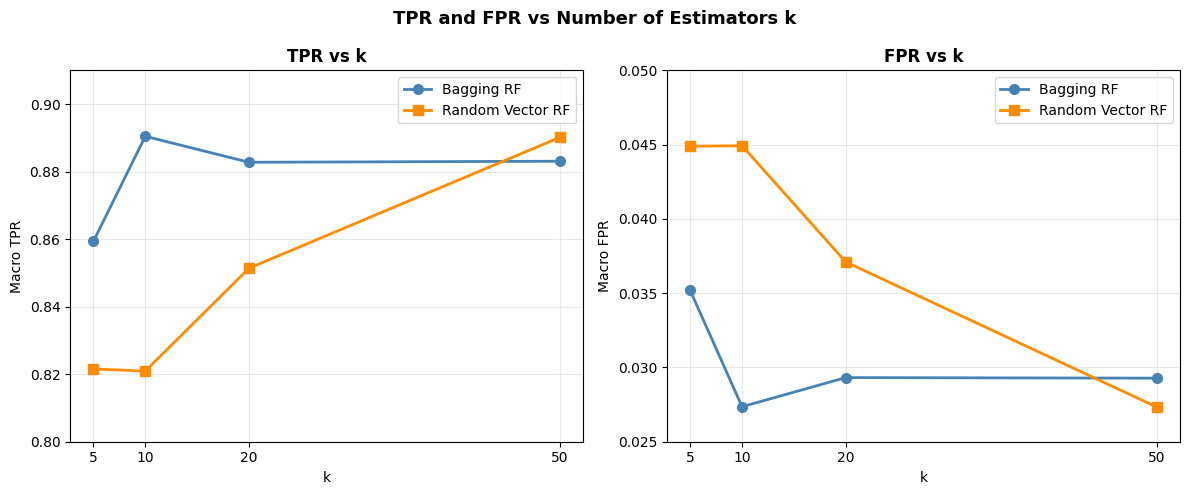

In [17]:
bag_tpr = df_results[df_results['Model'].str.startswith('Bagging RF')]['TPR'].values
rv_tpr  = df_results[df_results['Model'].str.startswith('Random Vector')]['TPR'].values
bag_fpr = df_results[df_results['Model'].str.startswith('Bagging RF')]['FPR'].values
rv_fpr  = df_results[df_results['Model'].str.startswith('Random Vector')]['FPR'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TPR
axes[0].plot(ks, bag_tpr, 'o-', color='steelblue',  lw=2, ms=7, label='Bagging RF')
axes[0].plot(ks, rv_tpr,  's-', color='darkorange', lw=2, ms=7, label='Random Vector RF')
axes[0].set_title('TPR vs k', fontsize=12, fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Macro TPR')
axes[0].set_xticks(ks); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.80, 0.91)

# FPR
axes[1].plot(ks, bag_fpr, 'o-', color='steelblue',  lw=2, ms=7, label='Bagging RF')
axes[1].plot(ks, rv_fpr,  's-', color='darkorange', lw=2, ms=7, label='Random Vector RF')
axes[1].set_title('FPR vs k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Macro FPR')
axes[1].set_xticks(ks); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.025, 0.050)

plt.suptitle('TPR and FPR vs Number of Estimators k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_tpr_fpr_k.png', dpi=120)
plt.show()

## Step 13 — Summary and Best Model Selection

In [18]:
print('='*65)
print('SUMMARY — Ranked by F1-Score (descending)')
print('='*65)
ranked = df_results.sort_values('F1', ascending=False).reset_index(drop=True)
for col in ['TPR', 'FPR', 'Precision', 'Recall', 'F1']:
    ranked[col] = ranked[col].map('{:.4f}'.format)
print(ranked.to_string(index=False))

print('\n' + '='*65)
best = df_results.loc[df_results['F1'].idxmax()]
print(f"Best Model : {best['Model']}")
print(f"  TPR      : {best['TPR']:.4f}")
print(f"  FPR      : {best['FPR']:.4f}")
print(f"  Precision: {best['Precision']:.4f}")
print(f"  Recall   : {best['Recall']:.4f}")
print(f"  F1-Score : {best['F1']:.4f}")

SUMMARY — Ranked by F1-Score (descending)
                Model    TPR    FPR Precision Recall     F1
      Bagging RF k=10 0.8905 0.0274    0.8927 0.8905 0.8906
Random Vector RF k=50 0.8902 0.0273    0.8913 0.8902 0.8901
      Bagging RF k=20 0.8828 0.0293    0.8837 0.8828 0.8818
      Bagging RF k=50 0.8831 0.0293    0.8818 0.8831 0.8804
       Bagging RF k=5 0.8594 0.0352    0.8618 0.8594 0.8596
Random Vector RF k=20 0.8514 0.0371    0.8570 0.8514 0.8515
          Naive Bayes 0.8443 0.0390    0.8453 0.8443 0.8429
Random Vector RF k=10 0.8209 0.0449    0.8327 0.8209 0.8215
 Random Vector RF k=5 0.8215 0.0449    0.8314 0.8215 0.8208
        Decision Tree 0.7969 0.0508    0.8044 0.7969 0.7962

Best Model : Bagging RF k=10
  TPR      : 0.8905
  FPR      : 0.0274
  Precision: 0.8927
  Recall   : 0.8905
  F1-Score : 0.8906


---
## Conclusions

1. **Both ensemble methods substantially outperform** the single-model baselines (Decision Tree and Naive Bayes) on all five metrics.
2. **Bagging RF** reaches near-optimal performance at k=10 (F1=0.8906), making it computationally efficient.
3. **Random Vector RF** shows a more gradual improvement and achieves peak performance at k=50 (F1=0.8901), benefiting from feature decorrelation.
4. **SMOTE** effectively balanced the training set without degrading test generalization.
5. For practitioners, a **Random Vector RF with k ≥ 20** is recommended for imbalanced multi-class tabular datasets.

---
## References

1. Breiman, L. (1996). Bagging Predictors. *Machine Learning*, 24(2), 123–140.  
2. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.  
3. Chawla et al. (2002). SMOTE. *JAIR*, 16, 321–357.  
4. Pedregosa et al. (2011). Scikit-learn. *JMLR*, 12, 2825–2830.  
5. Lemaître et al. (2017). Imbalanced-learn. *JMLR*, 18(17), 1–5.